In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
cleaned_data = pd.read_csv('/Users/garimau/dev/dsdp-ucsf/UCSFDelirium/Demographic/demographic.csv')



In [6]:
X_LR = cleaned_data.drop(columns=['Delirium at any time during hospitalization'], inplace=False)
y_LR = cleaned_data['Delirium at any time during hospitalization']

In [15]:
from sklearn.linear_model import LogisticRegression
X_trainLR, X_testLR, y_trainLR, y_testLR = train_test_split(X_LR, y_LR, test_size=0.2, random_state=42)

model = LogisticRegression(random_state=42)
model.fit(X_trainLR, y_trainLR)

/Users/garimau/dev/dsdp-ucsf/UCSFDelirium/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(random_state=42)

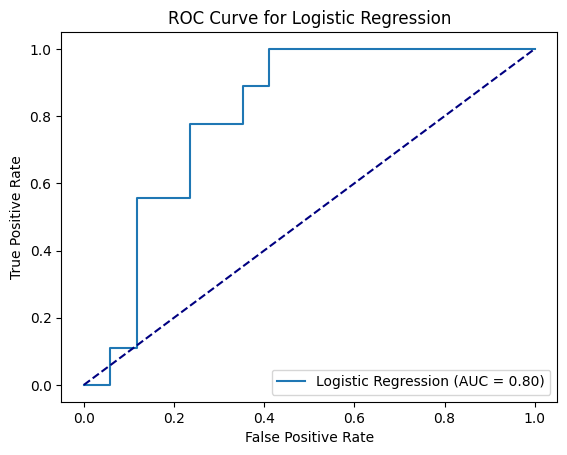

In [16]:
# Step 6: Make Predictions and Evaluate the Model
from sklearn.metrics import roc_curve, auc, roc_auc_score
y_pred_proba = model.predict_proba(X_testLR)[:, 1]  # Get probability scores
y_pred = model.predict(X_testLR)  # Get binary predictions

# Calculate AUC-ROC score
roc_auc = roc_auc_score(y_testLR, y_pred_proba)

# Step 7: Plot the ROC Curve
fpr, tpr, thresholds = roc_curve(y_testLR, y_pred_proba)

plt.figure()
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')  # Reference line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression')
plt.legend(loc='lower right')
plt.show()



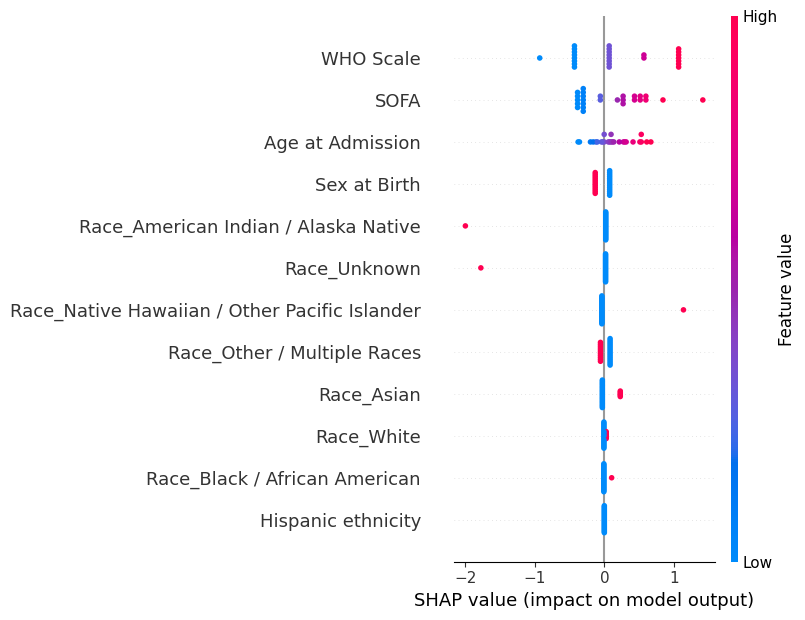

In [17]:
import shap
from sklearn.preprocessing import StandardScaler

# Step 9: Standardize the numerical features for SHAP (Optional, depending on the logistic regression convergence)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_trainLR), columns=X_trainLR.columns, index=X_trainLR.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_testLR), columns=X_testLR.columns, index=X_testLR.index)

# Step 10: Fit model on scaled data (replace original model with one trained on scaled data)
model.fit(X_train_scaled, y_trainLR)

# Step 11: Initialize SHAP explainer and calculate SHAP values for the test set
explainer = shap.Explainer(model, X_train_scaled)
shap_values = explainer(X_test_scaled)

# Step 12: Plot SHAP Summary Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_scaled, plot_type="dot", show=True)

In [18]:
X_fs = cleaned_data[['WHO Scale', 'SOFA', 'Sex at Birth']]
y_fs = cleaned_data['Delirium at any time during hospitalization']

In [19]:
X_trainFS, X_testFS, y_trainFS, y_testFS = train_test_split(X_fs, y_fs, test_size=0.2, random_state=42)

from sklearn.linear_model import LogisticRegression
model = LogisticRegression(random_state=42)
model.fit(X_trainFS, y_trainFS)


LogisticRegression(random_state=42)

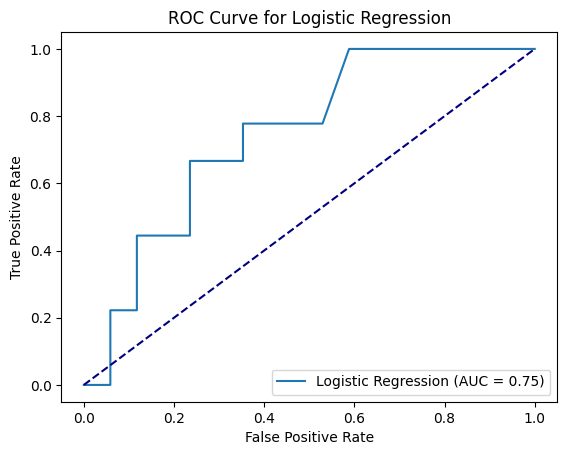

In [20]:
# Step 6: Make Predictions and Evaluate the Model
from sklearn.metrics import roc_curve, auc, roc_auc_score
y_pred_proba = model.predict_proba(X_testFS)[:, 1]  # Get probability scores
y_pred = model.predict(X_testFS)  # Get binary predictions

# Calculate AUC-ROC score
roc_auc = roc_auc_score(y_testFS, y_pred_proba)

# Step 7: Plot the ROC Curve
fpr, tpr, thresholds = roc_curve(y_testFS, y_pred_proba)

plt.figure()
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')  # Reference line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression')
plt.legend(loc='lower right')
plt.show()



In [21]:
# Step 8: Output additional metrics
from sklearn.metrics import roc_curve, auc, roc_auc_score,accuracy_score, confusion_matrix 

accuracy = accuracy_score(y_testFS, y_pred)
conf_matrix = confusion_matrix(y_testFS, y_pred)

print(f'ROC AUC Score: {roc_auc:.2f}')
print(f'Accuracy: {accuracy:.2f}')
print('Confusion Matrix:')
print(conf_matrix)

ROC AUC Score: 0.75
Accuracy: 0.69
Confusion Matrix:
[[16  1]
 [ 7  2]]


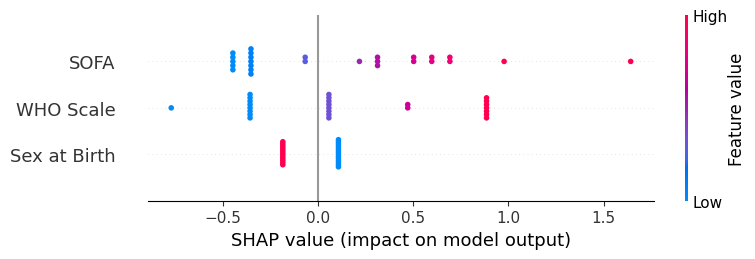

In [22]:
import shap
from sklearn.preprocessing import StandardScaler

# Step 9: Standardize the numerical features for SHAP (Optional, depending on the logistic regression convergence)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_trainFS), columns=X_trainFS.columns, index=X_trainFS.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_testFS), columns=X_testFS.columns, index=X_testFS.index)

# Step 10: Fit model on scaled data (replace original model with one trained on scaled data)
model.fit(X_train_scaled, y_trainFS)

# Step 11: Initialize SHAP explainer and calculate SHAP values for the test set
explainer = shap.Explainer(model, X_train_scaled)
shap_values = explainer(X_test_scaled)

# Step 12: Plot SHAP Summary Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_scaled, plot_type="dot", show=True)